##    Pima Indians Diabetes  - Logistic Regression Project

**Name:** Karthik Somaraju  
**Dataset Name:** Pima Indians Diabetes     
**Kaggle Link:** https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset/data

### About the dataset
The dataset used in this project is the Pima Indians Diabetes Database, obtained from Kaggle. It contains medical diagnostic information used to predict whether a person has diabetes. The input features include Pregnancies, Glucose, Blood Pressure, Skin Thickness, Insulin, BMI, Diabetes Pedigree Function, and Age. The target variable is Outcome, where 0 represents no diabetes and 1 represents diabetes.

### Objective
The objective of this project is to develop a Logistic Regression classification model that predicts whether a person has diabetes based on the given medical features. The project also aims to demonstrate the complete machine-learning workflow, including data preprocessing, median imputation, feature scaling, model training, evaluation, and interpretation of model coefficients.


## 1.Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

##2.Load the Diabetes Dataset

In [2]:
# Choose the diabetes CSV file from your computer
from google.colab import files
uploaded = files.upload()
csv_file = next(iter(uploaded))
df = pd.read_csv(csv_file)
print('Shape:', df.shape)
df.head()

Saving diabetes.csv to diabetes.csv
Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


##3.Dataset Information

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


##4.Check Missing Values

In [4]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


##5.Check Duplicate Rows

In [5]:
df.duplicated().sum()

np.int64(0)

## 6.Univariate Analysis - Outcome Percentage

In [6]:
# Univariate analysis
print(df["Outcome"].value_counts(normalize = True)*100)


Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


## 7.Univariate Analysis - Distribution of Diabetes

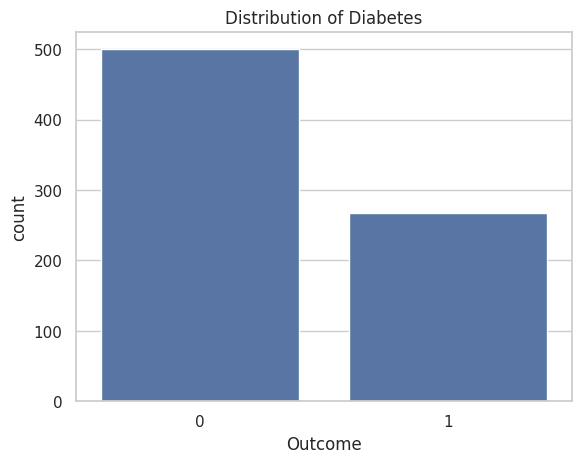

In [7]:
sns.countplot(data = df, x = "Outcome")
plt.title("Distribution of Diabetes")
plt.show()

## 8.Univariate Analysis - Distribution of Pregnancies

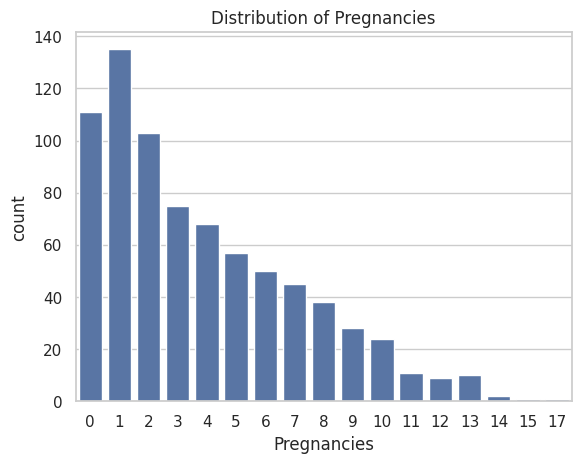

In [8]:
sns.countplot(data = df, x= "Pregnancies")
plt.title("Distribution of Pregnancies")
plt.show()

## 9.Bivariate Analysis - Age vs Diabetes

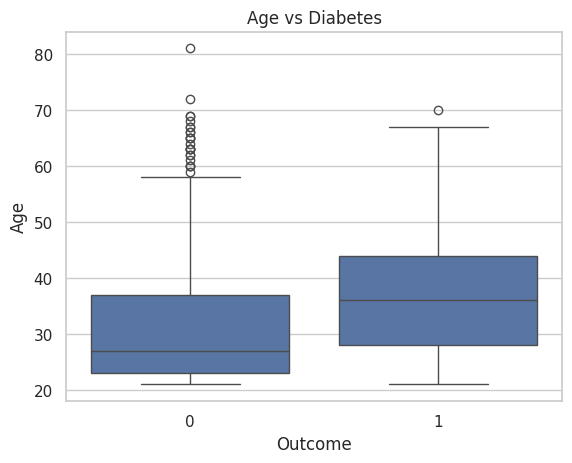

In [9]:
# Bivariate
sns.boxplot(data = df, x = "Outcome", y = "Age")
plt.title("Age vs Diabetes")
plt.show()

## 10.Select Numeric Columns

In [10]:
numeric_df = df.select_dtypes(include = ["int64","float64"]).columns

## 11.Multivariate Analysis - Correlation Matrix

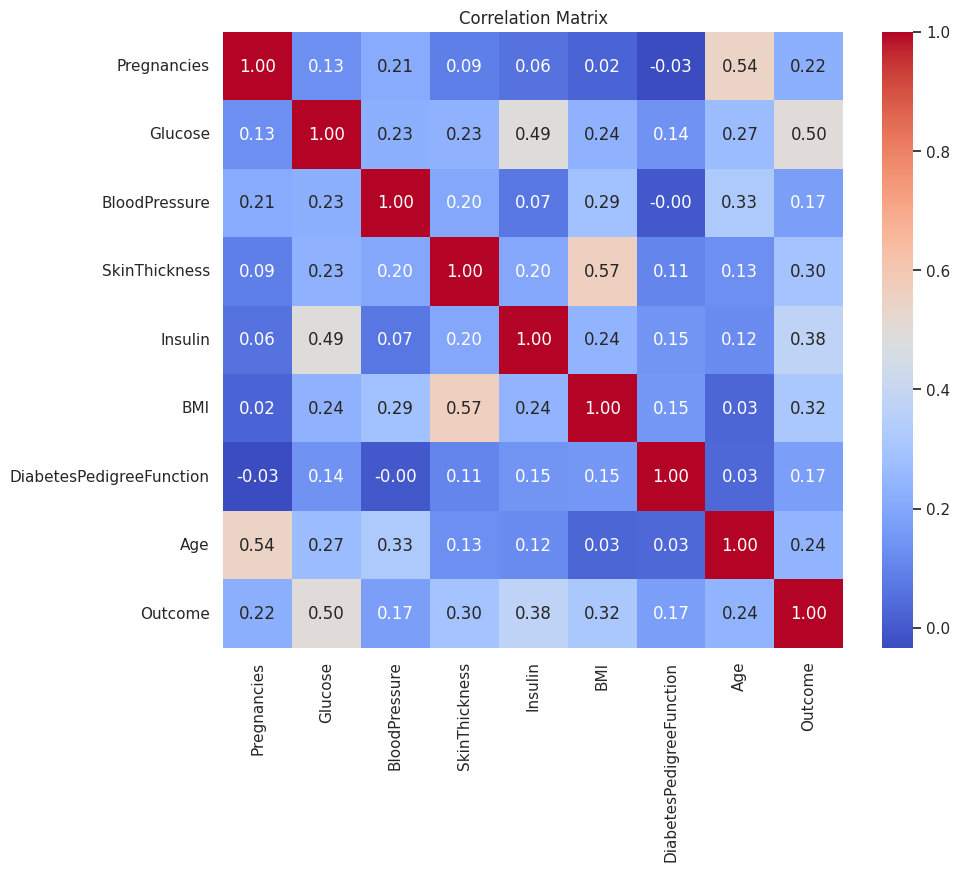

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Multivariate Analysis
plt.figure(figsize = (10, 8))
sns.heatmap(df[numeric_df].corr(), annot = True, cmap = "coolwarm",fmt= ".2f")
plt.title("Correlation Matrix")
plt.show()

##12.Outlier Detection - Boxplots

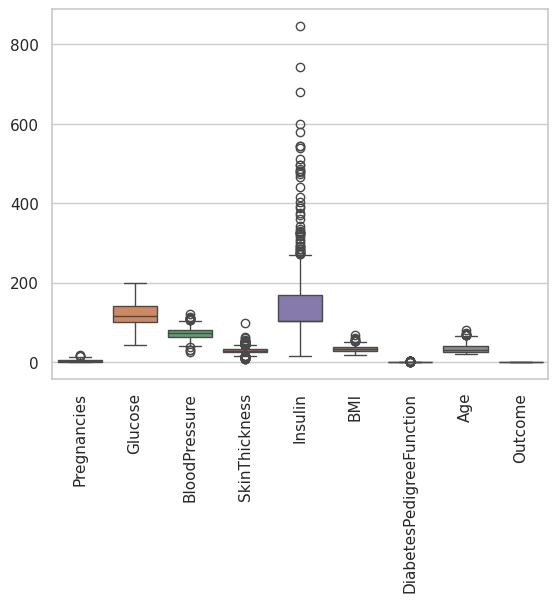

In [12]:
# Outlier detection
sns.boxplot(data =df[numeric_df])
plt.xticks(rotation = 90)
plt.show()

## 13.Define Columns with Invalid Zeros

In [13]:
# Treating invalid zeros
# Zero is not a valid value for these columns, so it is treated as missing
outlier_cols = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]
print((df[outlier_cols] == 0).sum())

Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


##  14.Replace Invalid Zeros with NaN

In [14]:
# Replace invalid zeros with NaN
for col in outlier_cols:
    df[col] = df[col].replace(0, np.nan)
print(df[outlier_cols].isnull().sum())

Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


## 15.Boxplots After Treating Invalid Zeros

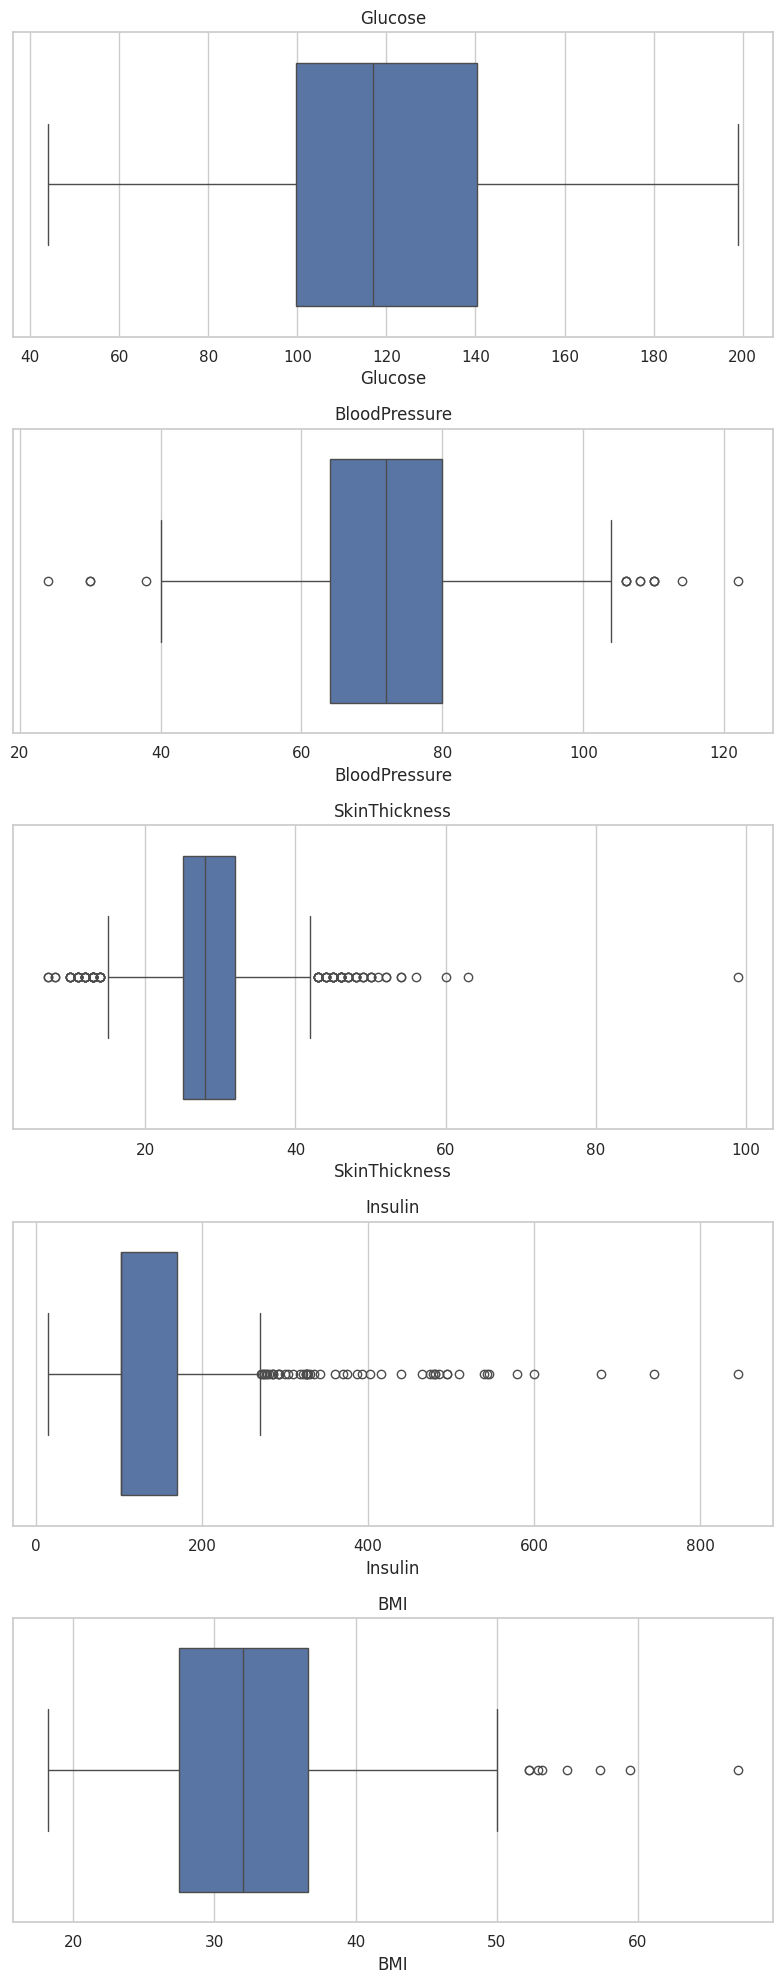

In [15]:
fig, axes = plt.subplots(len(outlier_cols),1, figsize = (8,20))
for i, col in enumerate(outlier_cols):
    sns.boxplot(data = df, x = col, ax = axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

## 16.Separate Features (X) and Target (y)

In [16]:
X = df.drop("Outcome", axis = 1)
y = df["Outcome"]

##  17.Train-Test Split

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

## 18.Check Train and Test Shapes

In [18]:
print(X_train.shape, X_test.shape,y_train.shape, y_test.shape)

(614, 8) (154, 8) (614,) (154,)


## 19.Median Imputation

In [19]:
from sklearn.impute import SimpleImputer
print("Missing values before imputation:\n", X_train.isnull().sum())
imputer = SimpleImputer(strategy = "median")
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)
print("Missing values after imputation:", np.isnan(X_train_imputed).sum())

Missing values before imputation:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64
Missing values after imputation: 0


## 20.Feature Scaling (StandardScaler)

In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)


## 21.Train the Logistic Regression Model

In [21]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(class_weight = "balanced", max_iter = 1000)
model.fit(X_train_scaled, y_train)


LogisticRegression(class_weight='balanced', max_iter=1000)

## 22.Predict on the Test Set

In [22]:
y_pred = model.predict(X_test_scaled)

## 23.Evaluation Metrics and Confusion Matrix

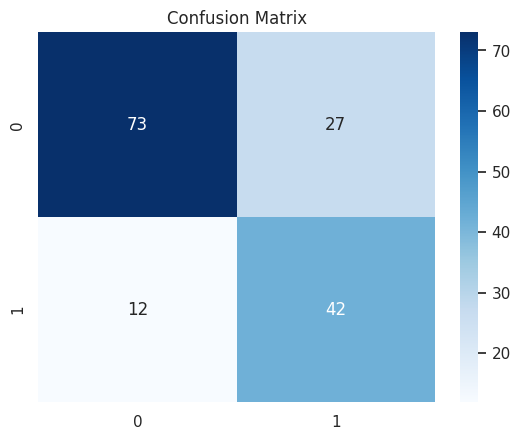

accuracy: 0.7467532467532467
precision: 0.6086956521739131
recall: 0.7777777777777778
f1 score: 0.6829268292682927
roc auc: 0.8272222222222222
classification report:
               precision    recall  f1-score   support

           0       0.86      0.73      0.79       100
           1       0.61      0.78      0.68        54

    accuracy                           0.75       154
   macro avg       0.73      0.75      0.74       154
weighted avg       0.77      0.75      0.75       154



In [23]:
# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label=1)
recall = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)
roc_auc = roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:, 1])
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)
sns.heatmap(conf_matrix, annot = True, fmt = "d", cmap = "Blues")
plt.title("Confusion Matrix")
plt.show()
print("accuracy:", accuracy)
print("precision:", precision)
print("recall:", recall)
print("f1 score:", f1)
print("roc auc:", roc_auc)
print("classification report:\n", class_report)

##  24.Interpret Model Coefficients

In [24]:
# Interpret coefficients
coef_df = pd.DataFrame({"Feature": X.columns, "Coefficient": model.coef_[0]}).sort_values("Coefficient", ascending = False)
print(coef_df)

                    Feature  Coefficient
1                   Glucose     0.904388
4                   Insulin     0.849074
5                       BMI     0.473949
0               Pregnancies     0.318641
3             SkinThickness     0.277745
6  DiabetesPedigreeFunction     0.227935
7                       Age     0.164487
2             BloodPressure     0.023701


## Conclusion
The Logistic Regression model successfully performed binary classification for diabetes prediction on the fixed test split. The model achieved an accuracy of approximately 74.7%, precision of 60.9%, recall of 77.8%, F1-score of 68.3%, and ROC-AUC of 0.827. The recall indicates that the model identified a relatively large proportion of the positive diabetes cases in the test set, which is useful for a screening-oriented classification task. The confusion matrix shows 73 true negatives, 27 false positives, 12 false negatives, and 42 true positives. Among the model coefficients, Glucose and Insulin have the strongest positive coefficients, followed by BMI and Pregnancies, indicating that higher values of these features are associated with higher predicted diabetes risk within this trained model. The project demonstrates the complete machine-learning workflow from data preparation and exploratory analysis to preprocessing, model training, evaluation, and interpretation. The results are intended for learning and model-analysis purposes and should not be treated as a medical diagnosis.